# Updated weighted average 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append('../')
import amglib.readers as rd

## Load data

In [373]:
img0 = rd.read_images('/Users/Shared/Data/P20240876/02_rawdata/04_Straw_NR_TR_yes_T27_R1/OB_{0:05d}.fits',first=1, last=5)

  0%|          | 0/5 [00:00<?, ?it/s]

### Adjust for dose

In [374]:
dose = np.median(img0[:,50:100,50:100].mean(axis=1),axis=1)
dose = dose[0]/dose
img0 = img0 * dose[:,None,None]
print(dose)

[1.         0.99465066 1.450056   1.0129107  0.99587655]


### Select sub image for testing

In [385]:
w=img0[:,100:300,100:300].copy()

## Define some functions

In [386]:
def mad(x, th = 1) :
    '''Computes the median absolute deviation
        
        Parameters:
        - x : A 3D data array with N slices arranged as [N,x,y] 
        - th : Regularization parameter to set a lower limit on the weights. Default th=1, to avoid 1/0.
        
        Returns the MAD per voxel
    '''
    
    m=np.median(x,axis=0)
    ma = np.abs(x - m)
    ma[ma<100] = 100
    
    return ma

In [387]:
def weighted_avg(x,w) :
    '''Computes a weighted average
        
        Parameters:
        - x : A 3D data array with N slices arranged as [N,x,y] 
        - w : Weight array
        
        Returns the weighted average
    '''
    sw=w.sum(axis=0)
    a = np.sum(x*w,axis=0)/(sw)
    
    return a

def weighted_avg2(x,w) :
    '''Computes a weighted average using a robust estimator
        
        Parameters:
        - x : A 3D data array with N slices arranged as [N,x,y] 
        - w : Weight array
        
        Returns the weighted average
    '''
    w2=w**2
    sw=w2.sum(axis=0)
    a = np.sum(x*w2,axis=0)/(sw)
    
    return a


## Compute different averages

In [388]:
ma  = mad(w,th=100) 
wa2 = weighted_avg2(w,1/ma**2)
wa  = weighted_avg(w,1/ma**2)
med = np.median(w,axis=0)
avg = w.mean(axis=0)

Text(0.5, 1.0, 'Single image')

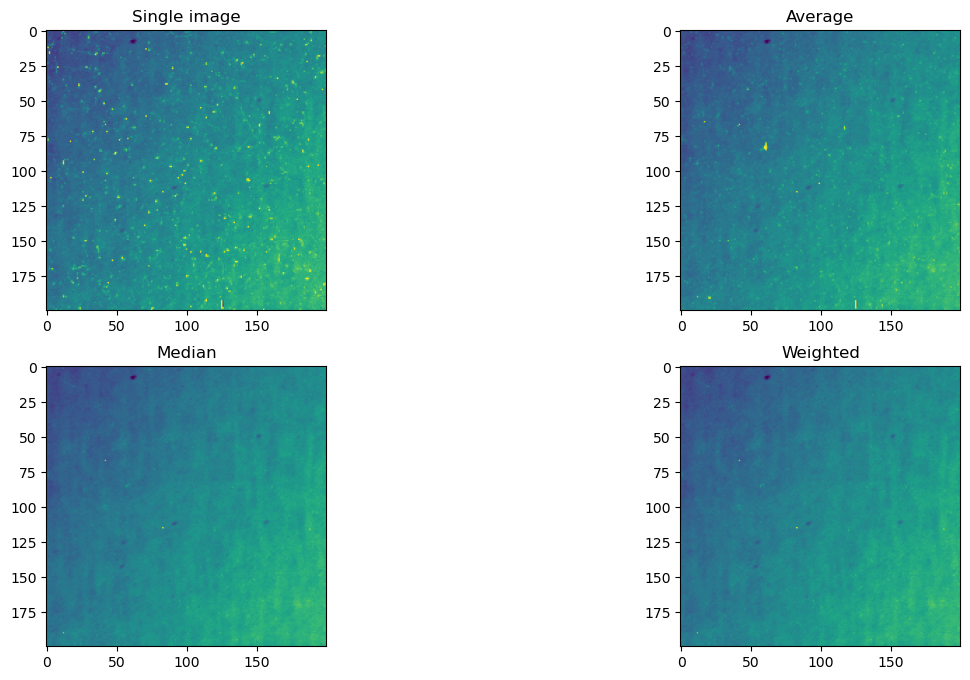

In [389]:
fig,ax = plt.subplots(2,2,figsize=(15,8))
ax=ax.ravel()
vmin=15000
vmax=25000
ax[3].imshow(wa2,vmin=vmin, vmax=vmax)
ax[3].set_title('Weighted')
ax[1].imshow(avg,vmin=vmin, vmax=vmax)
ax[1].set_title('Average')
ax[2].imshow(med,vmin=vmin, vmax=vmax)
ax[2].set_title('Median')
ax[0].imshow(w[0],vmin=vmin, vmax=vmax)
ax[0].set_title('Single image')

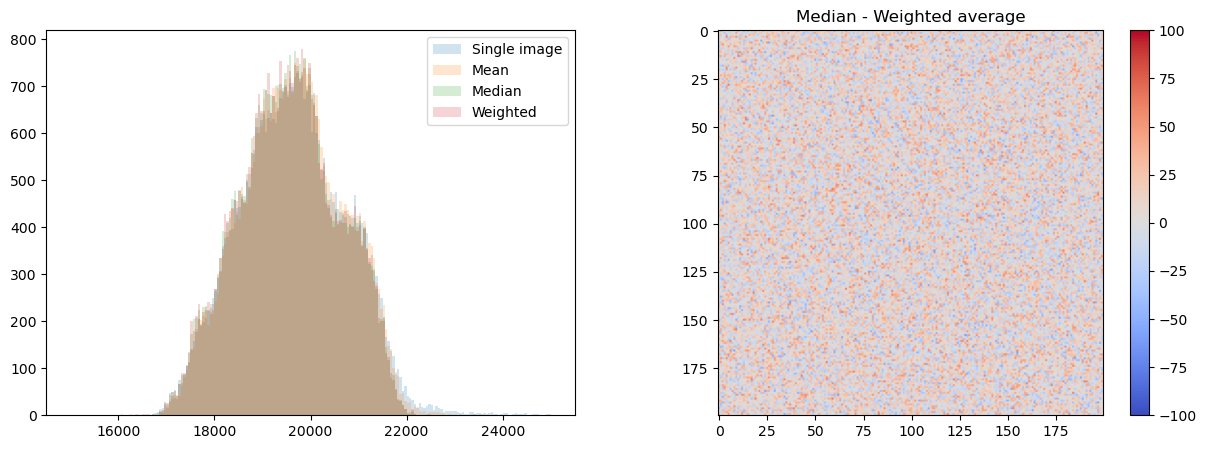

In [391]:
fig,ax = plt.subplots(1,2,figsize=(15,5))
ax=ax.ravel()

r=(15000,25000)
N=200
ax[0].hist(w[0].ravel(),bins=N,range=r,alpha=0.2,label='Single image');
ax[0].hist(avg.ravel(), bins=N,range=r,alpha=0.2,label='Mean');
ax[0].hist(med.ravel(), bins=N,range=r,alpha=0.2,label='Median');
ax[0].hist(wa2.ravel(), bins=N,range=r,alpha=0.2,label='Weighted');
ax[0].legend()

lim=100
a1=ax[1].imshow((med-wa2),vmin=-lim,vmax=lim,cmap = 'coolwarm')
ax[1].set_title('Median - Weighted average')
fig.colorbar(a1,ax=ax[1])